In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Modeling environment ready.")

Modeling environment ready.


In [2]:
DATA_DIR = Path(r"C:\Users\aduak\Downloads\capstone")
CLEAN_DIR = DATA_DIR / "cleaned"

cweeds = pd.read_csv(
    CLEAN_DIR / "clean_cweeds_4cities.csv",
    parse_dates=["timestamp"],
    low_memory=False
)

model_df = cweeds[
    [
        "timestamp",
        "city",
        "latitude",
        "longitude",
        "elevation_m",
        "ghi_wh_m2",
        "dry_bulb_temp_c",
        "dew_point_temp_c",
        "wind_speed_ms",
        "station_pressure_pa"
    ]
].copy()

In [3]:
model_df["year"] = model_df["timestamp"].dt.year
model_df["day_of_year"] = model_df["timestamp"].dt.dayofyear
model_df["hour"] = model_df["timestamp"].dt.hour

model_df["hour_sin"] = np.sin(
    2 * np.pi * model_df["hour"] / 24
)

model_df["hour_cos"] = np.cos(
    2 * np.pi * model_df["hour"] / 24
)

model_df["doy_sin"] = np.sin(
    2 * np.pi * model_df["day_of_year"] / 365.25
)

model_df["doy_cos"] = np.cos(
    2 * np.pi * model_df["day_of_year"] / 365.25
)

In [4]:
model_df = pd.get_dummies(
    model_df,
    columns=["city"],
    prefix="city",
    dtype=int
)

In [5]:
feature_columns = [
    "latitude",
    "longitude",
    "elevation_m",

    "dry_bulb_temp_c",
    "dew_point_temp_c",
    "wind_speed_ms",
    "station_pressure_pa",

    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",

    "city_Calgary",
    "city_Edmonton",
    "city_Lethbridge",
    "city_Medicine Hat"
]

target_column = "ghi_wh_m2"

X = model_df[feature_columns]
y = model_df[target_column]

In [6]:
train_mask = model_df["year"] <= 2011

validation_mask = (
    (model_df["year"] >= 2012) &
    (model_df["year"] <= 2014)
)

test_mask = model_df["year"] >= 2015

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[validation_mask]
y_val = y.loc[validation_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (490848, 15)
Validation: (105216, 15)
Test: (105216, 15)


In [7]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression trained.")

Linear Regression trained.


In [8]:
val_predictions = linear_model.predict(X_val)

In [9]:
val_r2 = r2_score(
    y_val,
    val_predictions
)

val_mae = mean_absolute_error(
    y_val,
    val_predictions
)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_predictions
    )
)

baseline_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "R2": [val_r2],
    "MAE": [val_mae],
    "RMSE": [val_rmse]
}).round(4)

display(baseline_results)

,Model,R2,MAE,RMSE
0,Linear Regression,0.6953,100.722,129.0732


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained.")

Random Forest trained.


In [11]:
rf_val_predictions = rf_model.predict(X_val)

In [12]:
rf_val_r2 = r2_score(
    y_val,
    rf_val_predictions
)

rf_val_mae = mean_absolute_error(
    y_val,
    rf_val_predictions
)

rf_val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_val_predictions
    )
)

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "R2": [rf_val_r2],
    "MAE": [rf_val_mae],
    "RMSE": [rf_val_rmse]
}).round(4)

display(rf_results)

,Model,R2,MAE,RMSE
0,Random Forest,0.8998,38.775,74.0207


In [13]:
model_comparison = pd.concat(
    [
        baseline_results,
        rf_results
    ],
    ignore_index=True
)

display(model_comparison)

,Model,R2,MAE,RMSE
0,Linear Regression,0.6953,100.722,129.0732
1,Random Forest,0.8998,38.775,74.0207


In [14]:
rf_configs = [
    {
        "name": "RF_A",
        "n_estimators": 100,
        "max_depth": 20,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    },
    {
        "name": "RF_B",
        "n_estimators": 150,
        "max_depth": 25,
        "min_samples_leaf": 3,
        "max_features": "sqrt"
    },
    {
        "name": "RF_C",
        "n_estimators": 150,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    }
]

In [15]:
rf_tuning_results = []
rf_models = {}

for config in rf_configs:

    print(f"Training {config['name']}...")

    model = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        max_features=config["max_features"],
        n_jobs=-1,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_val)

    r2 = r2_score(
        y_val,
        predictions
    )

    mae = mean_absolute_error(
        y_val,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            predictions
        )
    )

    rf_tuning_results.append({
        "Model": config["name"],
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

    rf_models[config["name"]] = model

    print(f"{config['name']} finished.")

Training RF_A...
RF_A finished.
Training RF_B...
RF_B finished.
Training RF_C...
RF_C finished.


In [16]:
rf_tuning_summary = (
    pd.DataFrame(rf_tuning_results)
    .sort_values("RMSE")
    .round(4)
)

display(rf_tuning_summary)

,Model,R2,MAE,RMSE
1,RF_B,0.9006,38.0272,73.7001
2,RF_C,0.9005,37.9536,73.7608
0,RF_A,0.8998,38.7750,74.0207


In [17]:
best_rf_name = (
    rf_tuning_summary
    .iloc[0]["Model"]
)

best_rf_model = rf_models[
    best_rf_name
]

print("Best Random Forest:", best_rf_name)

Best Random Forest: RF_B


In [18]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)

,Feature,Importance
0,hour_cos,0.503423
1,dry_bulb_temp_c,0.224917
2,doy_cos,0.090287
3,hour_sin,0.051795
4,dew_point_temp_c,0.047103
5,doy_sin,0.044954
6,station_pressure_pa,0.016913
7,wind_speed_ms,0.014809
8,latitude,0.001486
9,longitude,0.001264


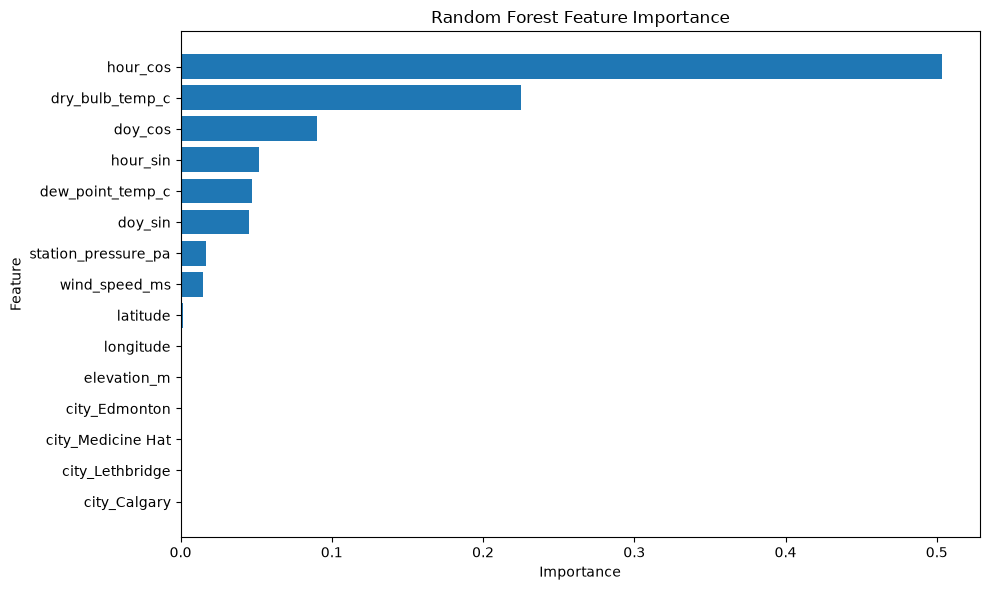

In [19]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [20]:
best_val_predictions = best_rf_model.predict(X_val)

residuals = y_val - best_val_predictions

residual_summary = pd.Series(residuals).describe().round(2)

display(residual_summary)

count    105216.00
mean          1.87
std          73.68
min        -718.33
25%          -5.10
50%          -0.43
75%           8.15
max         626.80
Name: ghi_wh_m2, dtype: float64

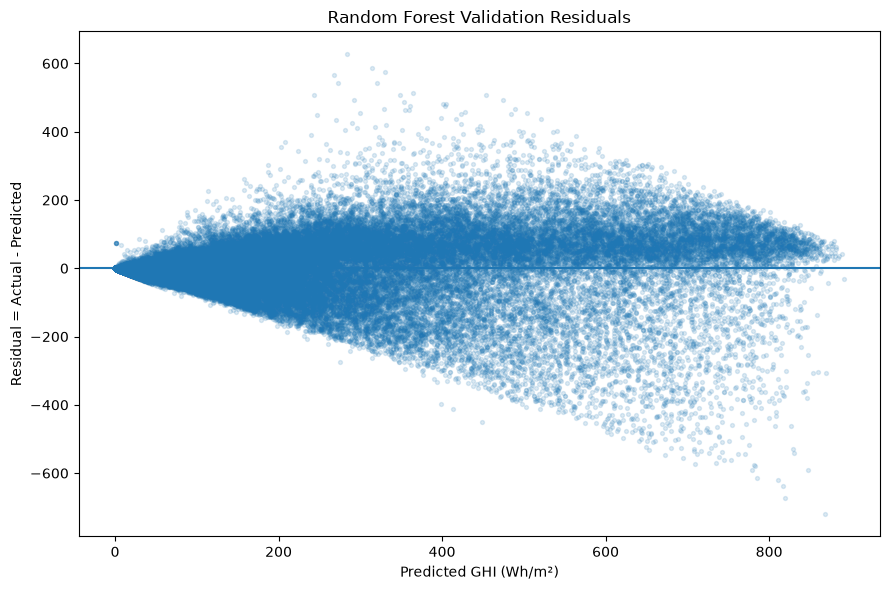

In [21]:
plt.figure(figsize=(9, 6))

plt.scatter(
    best_val_predictions,
    residuals,
    alpha=0.15,
    s=8
)

plt.axhline(0)

plt.title("Random Forest Validation Residuals")
plt.xlabel("Predicted GHI (Wh/m²)")
plt.ylabel("Residual = Actual - Predicted")

plt.tight_layout()
plt.show()

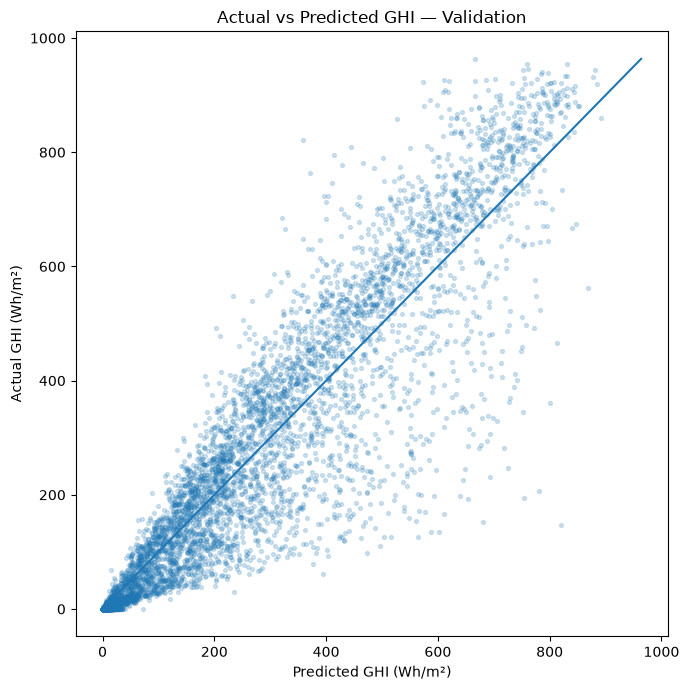

In [22]:
sample_idx = np.random.RandomState(42).choice(
    len(y_val),
    size=10000,
    replace=False
)

plt.figure(figsize=(7, 7))

plt.scatter(
    best_val_predictions[sample_idx],
    y_val.iloc[sample_idx],
    alpha=0.2,
    s=8
)

max_val = max(
    y_val.iloc[sample_idx].max(),
    best_val_predictions[sample_idx].max()
)

plt.plot(
    [0, max_val],
    [0, max_val]
)

plt.title("Actual vs Predicted GHI — Validation")
plt.xlabel("Predicted GHI (Wh/m²)")
plt.ylabel("Actual GHI (Wh/m²)")

plt.tight_layout()
plt.show()

In [23]:
test_predictions = best_rf_model.predict(X_test)

test_r2 = r2_score(
    y_test,
    test_predictions
)

test_mae = mean_absolute_error(
    y_test,
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

final_test_results = pd.DataFrame({
    "Model": ["Random Forest RF_B"],
    "R2": [test_r2],
    "MAE": [test_mae],
    "RMSE": [test_rmse]
}).round(4)

display(final_test_results)

,Model,R2,MAE,RMSE
0,Random Forest RF_B,0.9169,36.5911,69.543


## Model Evaluation Summary

A Linear Regression model was first trained as a baseline using geographic, meteorological, and cyclical time features. On the 2012–2014 validation period, the baseline achieved an R² of 0.6953, MAE of 100.72 Wh/m², and RMSE of 129.07 Wh/m².

A Random Forest Regressor was then evaluated to capture nonlinear relationships between weather conditions, geographic variables, and solar irradiance. Hyperparameter tuning compared three candidate configurations using the validation period. RF_B was selected as the final model because it achieved the lowest validation RMSE while maintaining lower complexity than the unrestricted alternative.

The selected Random Forest achieved:

- Validation R²: 0.9006
- Validation MAE: 38.03 Wh/m²
- Validation RMSE: 73.70 Wh/m²

The model was then evaluated once on the previously untouched 2015–2017 test period. Final test performance was:

- Test R²: 0.9169
- Test MAE: 36.59 Wh/m²
- Test RMSE: 69.54 Wh/m²

The stronger test performance indicates that the model generalized well to later years and did not exhibit obvious overfitting to the training period.

Feature importance analysis showed that time-of-day was the strongest predictor, followed by dry-bulb temperature and annual seasonality. These findings are consistent with the exploratory analysis, where irradiance followed strong daily and seasonal cycles.

Same-hour DNI and DHI were intentionally excluded from the prediction feature set because they are physically related components of solar irradiance and could introduce target leakage when predicting GHI.

In [24]:
test_results_detail = model_df.loc[test_mask, ["timestamp"]].copy()

# Recover city from dummy columns
city_dummy_cols = [
    "city_Calgary",
    "city_Edmonton",
    "city_Lethbridge",
    "city_Medicine Hat"
]

test_results_detail["city"] = (
    model_df.loc[test_mask, city_dummy_cols]
    .idxmax(axis=1)
    .str.replace("city_", "", regex=False)
)

test_results_detail["actual_ghi"] = y_test.values
test_results_detail["predicted_ghi"] = test_predictions

In [25]:
city_test_results = []

for city, group in test_results_detail.groupby("city"):

    r2 = r2_score(
        group["actual_ghi"],
        group["predicted_ghi"]
    )

    mae = mean_absolute_error(
        group["actual_ghi"],
        group["predicted_ghi"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            group["actual_ghi"],
            group["predicted_ghi"]
        )
    )

    city_test_results.append({
        "City": city,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

city_test_summary = (
    pd.DataFrame(city_test_results)
    .round(4)
)

display(city_test_summary)

,City,R2,MAE,RMSE
0,Calgary,0.9047,38.9873,73.7264
1,Edmonton,0.9174,34.3241,65.5330
2,Lethbridge,0.9222,36.7826,69.8574
3,Medicine Hat,0.9220,36.2705,68.8091


### City-Level Test Performance

The final Random Forest model maintained strong predictive performance across all four Alberta cities. Test R² values ranged from 0.9047 in Calgary to 0.9222 in Lethbridge, indicating that model accuracy was geographically consistent rather than being driven by a single station.

Edmonton achieved the lowest RMSE at 65.53 Wh/m², while Calgary had the highest RMSE at 73.73 Wh/m². Despite these differences, all cities achieved R² values above 0.90, demonstrating robust generalization across the four-city study area.